In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

2025-06-30 00:23:42.405453: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-30 00:23:42.921167: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-30 00:23:44.825238: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [27]:
import yfinance as yf

ticker = 'AAPL'
start_date = '2020-02-01'
end_date = '2023-12-31'

ticker = yf.Ticker('AAPL')
df = ticker.history(start='2020-02-01', end='2023-12-31')

In [41]:
def fibonacci_weights(length):
    fib = [1, 1]
    while len(fib) < length:
        fib.append(fib[-1] + fib[-2])
    weights = np.array(fib[-length:])
    return weights / weights.sum()

In [42]:
def fwma(series, length=8):
    weights = fibonacci_weights(length)
    return series.rolling(length).apply(lambda x: np.sum(weights * x), raw=True)

In [43]:
def add_technical_indicators(df):
    df = df.copy()

    # ✅ 멀티인덱스 컬럼 문제 해결
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    # ✅ 컬럼 이름 깨끗하게
    df.columns = df.columns.str.strip()

    # ✅ High/Low/Close NaN 제거
    df = df.dropna(subset=['High', 'Low', 'Close'])

    # ✅ 로그수익률 + 누적 로그수익률
    df['log_return'] = np.log(df['Close']).diff()
    df['CUMLOGRET_1'] = df['log_return'].cumsum()

    # ✅ 이동평균
    df['EMA_8'] = ta.ema(df['Close'], length=8)
    df['SMA_8'] = ta.sma(df['Close'], length=8)

    # ✅ MACD
    macd = ta.macd(df['Close'], fast=8, slow=21, signal=9)
    df = pd.concat([df, macd], axis=1)

    # ✅ Bollinger Bands
    bb = ta.bbands(df['Close'], length=5, std=2)
    df = pd.concat([df, bb], axis=1)

    # ✅ Stochastic RSI
    stoch_rsi = ta.stochrsi(df['Close'], length=14, rsi_length=14, k=3, d=3)
    df = pd.concat([df, stoch_rsi], axis=1)

    # ✅ Stochastic Oscillator
    stoch = ta.stoch(df['High'], df['Low'], df['Close'], k=3, d=3, smooth_k=14)
    df = pd.concat([df, stoch], axis=1)

    # ✅ Ichimoku → append=True로 df에 직접 추가
    df.ta.ichimoku(conversion=9, base=26, span=52, append=True)

    # ✅ FWMA (수동 구현)
    df['FWMA_8'] = fwma(df['Close'], length=8)

    # ✅ KDJ (수동 계산)
    if 'STOCHk_9_3_3' in df.columns and 'STOCHd_9_3_3' in df.columns:
        df['K_9_3'] = df['STOCHk_9_3_3']
        df['D_9_3'] = df['STOCHd_9_3_3']
        df['J_9_3'] = 3 * df['K_9_3'] - 2 * df['D_9_3']

    # ✅ 모든 NaN 행 제거
    df = df.dropna()

    return df

In [44]:
df = add_technical_indicators(df)


✅ 상관계수 >= 0.8 선택된 피처:
['EMA_8', 'SMA_8', 'BBL_5_2.0', 'BBM_5_2.0', 'BBU_5_2.0', 'ISA_9', 'ISB_26', 'ITS_9', 'IKS_26', 'ICS_26', 'FWMA_8']


FWMA_8       0.989828
BBM_5_2.0    0.986988
EMA_8        0.986372
BBU_5_2.0    0.984657
SMA_8        0.983127
BBL_5_2.0    0.981533
ITS_9        0.981097
IKS_26       0.963107
ISA_9        0.894837
ISB_26       0.886289
ICS_26       0.862872
dtype: float64

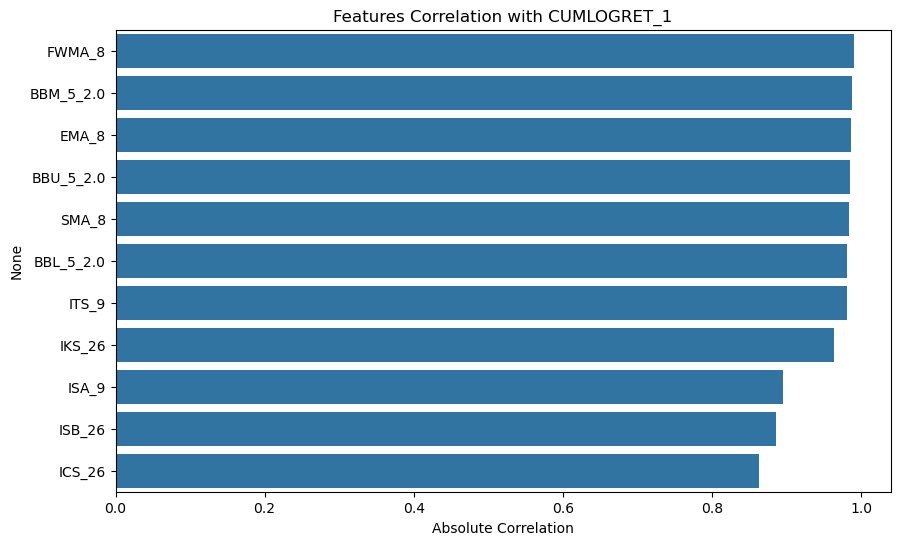

In [47]:
# 타깃 변수
target_col = 'CUMLOGRET_1'

# 기술지표 후보 컬럼
exclude_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', target_col]
features = df.columns.drop(exclude_cols)

# 상관계수 계산
corr_series = df[features].corrwith(df[target_col]).abs()

# Threshold 기반 선택
threshold = 0.8
selected_features = corr_series[corr_series >= threshold].index.tolist()

print(f"\n✅ 상관계수 >= {threshold} 선택된 피처:")
print(selected_features)

# 상세 상관계수 테이블
corr_result = corr_series[corr_series >= threshold].sort_values(ascending=False)
display(corr_result)

# 시각화
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x=corr_result.values, y=corr_result.index)
plt.title(f'Features Correlation with {target_col}')
plt.xlabel('Absolute Correlation')
plt.show()


In [51]:
df_temp=df.copy()

In [64]:
df=df_temp.copy()

In [63]:
df_temp.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'log_return', 'CUMLOGRET_1', 'EMA_8', 'SMA_8', 'MACD_8_21_9',
       'MACDh_8_21_9', 'MACDs_8_21_9', 'BBL_5_2.0', 'BBM_5_2.0', 'BBU_5_2.0',
       'BBB_5_2.0', 'BBP_5_2.0', 'STOCHRSIk_14_14_3_3', 'STOCHRSId_14_14_3_3',
       'STOCHk_3_3_14', 'STOCHd_3_3_14', 'ISA_9', 'ISB_26', 'ITS_9', 'IKS_26',
       'ICS_26', 'FWMA_8'],
      dtype='object')

In [67]:
selected_features.append('log_return')
selected_features

['EMA_8',
 'SMA_8',
 'BBL_5_2.0',
 'BBM_5_2.0',
 'BBU_5_2.0',
 'ISA_9',
 'ISB_26',
 'ITS_9',
 'IKS_26',
 'ICS_26',
 'FWMA_8',
 'log_return']

In [69]:
df=df[selected_features]
df.columns

Index(['EMA_8', 'SMA_8', 'BBL_5_2.0', 'BBM_5_2.0', 'BBU_5_2.0', 'ISA_9',
       'ISB_26', 'ITS_9', 'IKS_26', 'ICS_26', 'FWMA_8', 'log_return'],
      dtype='object')

In [70]:
split_index = int(len(df) * 0.7)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]


In [71]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df[selected_features])
test_scaled = scaler.transform(test_df[selected_features])


In [72]:
def create_window_data(data, target_col_index, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, target_col_index])
    return np.array(X), np.array(y)

target_col_index = selected_features.index('log_return')

X_train, y_train = create_window_data(train_scaled, target_col_index)
X_test, y_test = create_window_data(test_scaled, target_col_index)


In [73]:
model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_test, y_test))


2025-06-30 03:53:26.039397: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-30 03:53:26.216613: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-30 03:53:26.217244: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-30 03:53:26.221078: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-30 03:53:26.221886: I tensorflow/compile

Epoch 1/100


2025-06-30 03:53:27.894504: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-06-30 03:53:28.295245: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x30d36eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-06-30 03:53:28.295287: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-06-30 03:53:28.344795: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-06-30 03:53:28.456199: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2025-06-30 03:53:28.821264: I ./tensorflow/compiler/jit/device_compiler.h:180] Compiled cluster using XLA!  This line is logged at most once for the lifetime o

70/70 [==============================] - 15s 178ms/step - loss: 0.0463 - val_loss: 0.0101
Epoch 2/100
70/70 [==============================] - 14s 195ms/step - loss: 0.0179 - val_loss: 0.0070
Epoch 3/100
70/70 [==============================] - 14s 193ms/step - loss: 0.0169 - val_loss: 0.0060
Epoch 4/100
70/70 [==============================] - 13s 192ms/step - loss: 0.0155 - val_loss: 0.0052
Epoch 5/100
70/70 [==============================] - 14s 194ms/step - loss: 0.0163 - val_loss: 0.0064
Epoch 6/100
70/70 [==============================] - 14s 196ms/step - loss: 0.0147 - val_loss: 0.0052
Epoch 7/100
70/70 [==============================] - 13s 191ms/step - loss: 0.0153 - val_loss: 0.0062
Epoch 8/100
70/70 [==============================] - 14s 193ms/step - loss: 0.0140 - val_loss: 0.0050
Epoch 9/100
70/70 [==============================] - 13s 191ms/step - loss: 0.0139 - val_loss: 0.0054
Epoch 10/100
70/70 [==============================] - 14s 195ms/step - loss: 0.0142 - val_loss

In [74]:
y_pred_scaled = model.predict(X_test)


7/7 [==============================] - 0s 49ms/step


In [75]:
# y_pred_scaled와 y_test는 스케일된 로그수익률
# 역스케일링 → 학습셋으로 fit된 scaler 기준으로
def inverse_transform_log_return(scaled_vals, feature_index, scaler):
    # 모든 features zero로 초기화
    dummy = np.zeros((len(scaled_vals), len(selected_features)))
    dummy[:, feature_index] = scaled_vals.flatten()
    inversed = scaler.inverse_transform(dummy)
    return inversed[:, feature_index]

predicted_log_returns = inverse_transform_log_return(y_pred_scaled, target_col_index, scaler)
actual_log_returns = inverse_transform_log_return(y_test, target_col_index, scaler)


In [79]:
df_temp.Close

Date
2020-05-22 00:00:00-04:00     77.495789
2020-05-26 00:00:00-04:00     76.970863
2020-05-27 00:00:00-04:00     77.306213
2020-05-28 00:00:00-04:00     77.340248
2020-05-29 00:00:00-04:00     77.264900
                                ...    
2023-11-15 00:00:00-05:00    186.643204
2023-11-16 00:00:00-05:00    188.330841
2023-11-17 00:00:00-05:00    188.310959
2023-11-20 00:00:00-05:00    190.058182
2023-11-21 00:00:00-05:00    189.254044
Name: Close, Length: 882, dtype: float64

In [80]:
len(train_df)

617

In [81]:
train_df

,EMA_8,SMA_8,BBL_5_2.0,BBM_5_2.0,BBU_5_2.0,ISA_9,ISB_26,ITS_9,IKS_26,ICS_26,FWMA_8,log_return
Date,,,,,,,,,,,,
2020-05-22 00:00:00-04:00,76.305893,76.185003,75.815653,76.942671,78.069689,62.291679,65.416927,75.469019,71.155853,88.652687,77.012941,0.006418
2020-05-26 00:00:00-04:00,76.453664,76.460831,75.974211,77.028700,78.083190,62.922425,65.416927,75.876079,71.562913,88.485008,77.020457,-0.006797
2020-05-27 00:00:00-04:00,76.643120,76.721163,76.772430,77.270258,77.768085,63.505301,65.416927,75.876079,71.562913,88.485008,77.134625,0.004347
2020-05-28 00:00:00-04:00,76.798037,77.041335,76.814327,77.222624,77.630921,63.640421,65.416927,75.876079,72.383314,90.851997,77.243849,0.000440
2020-05-29 00:00:00-04:00,76.901784,77.131858,76.933166,77.275603,77.618039,63.850677,65.416927,77.104520,72.706866,90.570114,77.249155,-0.000975
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-26 00:00:00-04:00,145.076619,144.364880,140.379655,146.220227,152.060800,156.990123,156.742668,143.243773,144.441251,145.919815,146.974559,-0.019822
2022-10-27 00:00:00-04:00,144.551051,144.659317,141.552743,146.498157,151.443570,156.990123,156.742668,144.268791,142.460266,144.754898,145.363866,-0.030939
2022-10-28 00:00:00-04:00,146.538323,146.136452,141.026617,148.167725,155.308832,156.990123,156.742668,146.905185,143.830194,141.082474,148.558958,0.072834


In [82]:
last_train_close = df_temp['Close'].iloc[len(train_df) - 1]

predicted_prices = [last_train_close]
actual_prices = [last_train_close]

for pred_log_ret in predicted_log_returns:
    predicted_prices.append(predicted_prices[-1] * np.exp(pred_log_ret))

for act_log_ret in actual_log_returns:
    actual_prices.append(actual_prices[-1] * np.exp(act_log_ret))

predicted_prices = np.array(predicted_prices[1:])
actual_prices = np.array(actual_prices[1:])


In [83]:
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)
mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
r2 = r2_score(actual_prices, predicted_prices)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R2: {r2:.4f}")


RMSE: 5.88
MAE: 4.30
MAPE: 2.34%
R2: 0.8233


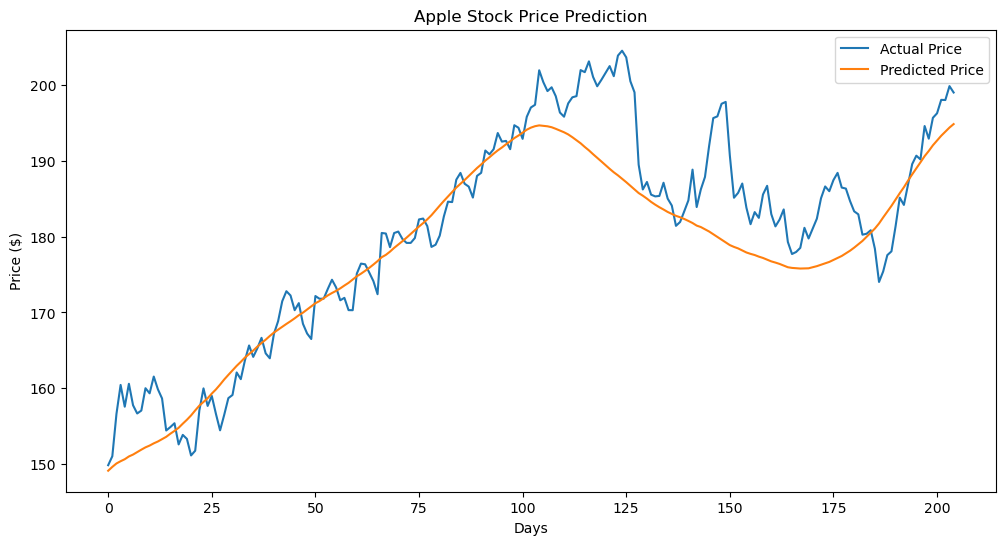

In [84]:
plt.figure(figsize=(12,6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.title('Apple Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.show()
